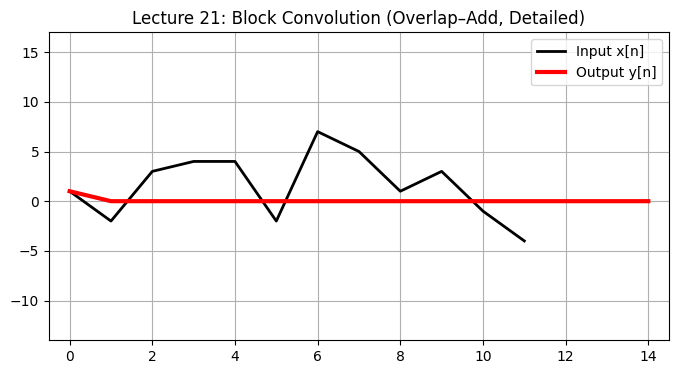

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 21: Block Convolution (Overlap–Add)
# with more animation frames
# -----------------------------

# Input signal
x = np.array([1, -2, 3, 4, 4, -2, 7, 5, 1, 3, -1, -4])
N = len(x)

# FIR filter (lecture-style example)
b = np.array([1, -3, -3, 1])
M = len(b)

# Block length
L = 6

# Split input into blocks
blocks = [x[i:i+L] for i in range(0, N, L)]

# Convolve each block
conv_blocks = [np.convolve(blk, b) for blk in blocks]

# Output length
y_len = N + M - 1
n = np.arange(y_len)

# Total frames:
# one frame per output sample per block
frames_per_block = max(len(cb) for cb in conv_blocks)
total_frames = len(conv_blocks) * frames_per_block

# Plot setup
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(-0.5, y_len - 0.5)
ax.set_ylim(min(x) - 10, max(x) + 10)
ax.grid(True)
ax.set_title("Lecture 21: Block Convolution (Overlap–Add, Detailed)")

# Static input
ax.plot(np.arange(N), x, 'k', lw=2, label="Input x[n]")

# Animated output
y_line, = ax.plot([], [], 'r', lw=3, label="Output y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (same Lecture 9 style)
# -----------------------------
def update(frame):
    y_partial = np.zeros(y_len)

    block_idx = frame // frames_per_block
    sample_idx = frame % frames_per_block

    # Add completed blocks fully
    for i in range(block_idx):
        shift = i * L
        y_partial[shift:shift + len(conv_blocks[i])] += conv_blocks[i]

    # Add current block partially
    if block_idx < len(conv_blocks):
        shift = block_idx * L
        length = min(sample_idx + 1, len(conv_blocks[block_idx]))
        y_partial[shift:shift + length] += conv_blocks[block_idx][:length]

    y_line.set_data(n, y_partial)
    return (y_line,)

anim = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=200
)

HTML(anim.to_jshtml())
